In [7]:
import numpy as np

import sys
sys.path.append('./src')

Coordinates:
[[71.42357807 88.27506079]
 [32.93782144 12.93412317]
 [87.95821474 21.67341029]
 [71.1897263  37.650873  ]]

Distance Matrix:
[[ 0.         84.60147957 68.62342209 50.62472791]
 [84.60147957  0.         55.7101321  45.54257291]
 [68.62342209 55.7101321   0.         23.16163896]
 [50.62472791 45.54257291 23.16163896  0.        ]]


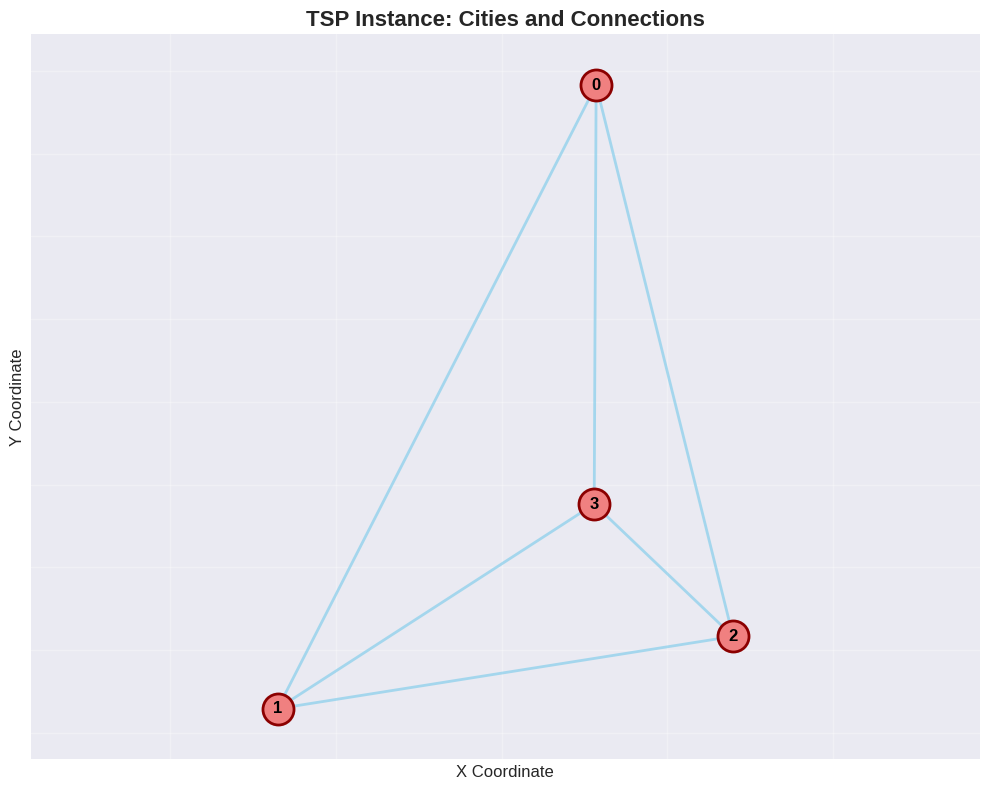

In [8]:
from tsp import TSPInstance

n_cities = 4  # Change this to the desired number of cities
tsp_instance = TSPInstance(n_cities)
print("Coordinates:")
print(tsp_instance.coords)
print("\nDistance Matrix:")
print(tsp_instance.dist_matrix)

# Plot the instance
tsp_instance.plot_tsp_instance()

In [9]:
from bloch_sphere_encoding import BlochSphereEncoder

encoder = BlochSphereEncoder(tsp_instance)
print(encoder.dist_matrix)
bloch_tsp = encoder.get_encoded_instance()

bloch_tsp.plot_all_cities_on_bloch_sphere()

[[0.         1.57079633 1.27413161 0.93994972]
 [1.57079633 0.         1.03437045 0.8455893 ]
 [1.27413161 1.03437045 0.         0.43004233]
 [0.93994972 0.8455893  0.43004233 0.        ]]
Cost from city 0 to city 1: 0.7853981633974483
Cost from city 0 to city 2: 0.6370658048597284
Cost from city 0 to city 3: 0.4699748577306295
Cost from city 1 to city 0: 0.7853981633974483
Cost from city 1 to city 2: 1.0536110995846175
Cost from city 1 to city 3: 1.1480016746654518
Cost from city 2 to city 0: 0.6370658048597284
Cost from city 2 to city 1: 0.517185227210279
Cost from city 2 to city 3: 0.21502116500796067
Cost from city 3 to city 0: 1.100821469064267
Cost from city 3 to city 1: 1.1480016746654518
Cost from city 3 to city 2: 1.3557751617869354


In [10]:
bloch_tsp.plot_all_states_on_bloch_sphere()

In [11]:
initial_state = bloch_tsp.get_city_state(0)

expected_final_state = bloch_tsp.get_city_state(2)

travel_operator = bloch_tsp.travel_operators[0][2]
computed_final_state = initial_state.evolve(travel_operator.up).evolve(travel_operator.down)

print("Initial State (City 0):", initial_state)
print("Expected Final State (City 2):", expected_final_state)
print("Computed Final State after applying travel operator:", computed_final_state)
print("States match:", np.allclose(expected_final_state.data, computed_final_state.data))

Initial State (City 0): Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Expected Final State (City 2): Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
Computed Final State after applying travel operator: Statevector([ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
            dims=(2,))
States match: True


In [12]:
routes = bloch_tsp.get_allowed_routes()
print("Allowed Routes:")
for route in routes:
    print(route)

Allowed Routes:
(0, 1, 2, 3, 0)
(0, 1, 3, 2, 0)
(0, 2, 1, 3, 0)
(0, 2, 3, 1, 0)
(0, 3, 1, 2, 0)
(0, 3, 2, 1, 0)
